# Defining Geometry Metadata in ESCDF

For a given test or analysis where responses are measured or computed, we will generally need to know the location at which the response was obtained, as well as the direction in which the response was obtained.  ESCDF uses the `geometry` data type to store this information.  This document will describe how ESCDF handles geometry definitions, as well as how they map to data that might also be stored in a given ESCDF file.

## Preliminary Setup
To start, we will perform preliminary operations needed by our respective programming languages. In Matlab, we clear and reset the workspace. In Python, we import our modules. In both cases, we need to ensure the respective libraries needed are on the Matlab or Python path.

In [1]:
% Geometry with ESCDF

% Clear the workspace
clear; clc; close all;

% If you don't have ESCDF on your path, uncomment the following addpath 
% function and point it to the correct path

% addpath(genpath('/path/to/escdf'));

## Creation of the Source Geometry
A `geometry` object may come from many sources.  Geometry may come from the nodes of a finite element model; it may come from the measurement of sensor locations on a test; it may even come from a bespoke file type such as a Universal File, an STL file, or some other geometric representation.  Since this document cannot hope to cover all possible sources of geometry information, we will assume that we can extract whatever geometry information is needed from that source and package it into simple variables defining the positions of nodes in the geometry in ($x$, $y$, $z$) coordinates, as well as the unit vectors specifying the directions in which responses on that geometry might be obtained.

For this example, we will generate a conical geometry, and assume that measurements are made in local directions that are tangential and perpendicular to the cone's surface.  This first portion of the code will construct the geometry.  We will therefore generate positions corresponding to each node, as well as unit vectors for the local $x$, $y$, and $z$ coordinate system directions.

In [2]:
% Define the geometry of the cone
cone_angle = 10; % degrees
axial_stations = 0.1:0.3:2.2;
radial_stations = tan(cone_angle*pi/180)*axial_stations;
circumferential_stations = 0:30:330;

% Go through and construct the array of node positions.
% We will construct it so the nodes are in a 2D array of
% axial stations and circumferential stations
node_positions = zeros(3,length(circumferential_stations),length(axial_stations));
node_ids = zeros(length(circumferential_stations),length(axial_stations));
node_x_directions = zeros(3,length(circumferential_stations),length(axial_stations));
node_y_directions = zeros(3,length(circumferential_stations),length(axial_stations));
node_z_directions = zeros(3,length(circumferential_stations),length(axial_stations));
% Loop through axial and radial stations.  We will use enumerate
% to get the index as well as the values, and we will use zip
% to get one axial and one radial position with each loop.
for col_ind = 1:length(axial_stations)
    axial_position = axial_stations(col_ind);
    radial_position = radial_stations(col_ind);
    % Loop through circumferential stations, again using
    % enumerate to get the index as well as the value
    for row_ind = 1:length(circumferential_stations)
        circumferential_position = circumferential_stations(row_ind);
        % Add an entry to the last row we constructed
        node_positions(:,row_ind,col_ind) = [
            radial_position*cos(circumferential_position*pi/180), ...
            radial_position*sin(circumferential_position*pi/180), ...
            axial_position ...
            ];
        % There are 12 circumferential stations, so we need to
        % start the axial identifiers in the 100's place of the
        % identification number.
        node_ids(row_ind, col_ind) = 100*(col_ind) + row_ind;
        % Create the rotation matrices for the coordinate system.
        % This will be a compound rotation, first about the Y-axis
        % we rotate the negative cone angle, then about the Z-axis
        % we rotate the negative circumferential station angle
        s = sin(-cone_angle*pi/180);
        c = cos(-cone_angle*pi/180);
        R_y = [c, 0, s; ...
               0, 1, 0; ...
               -s, 0, c];
        s = sin(-circumferential_position*pi/180);
        c = cos(-circumferential_position*pi/180);
        R_z = [c, -s, 0; ...
               s, c, 0;  ...
               0, 0, 1];
        rot_mat = R_y * R_z;
        % The unit vectors for each local direction are the rows
        % of the rotation matrix
        node_x_directions(:,row_ind,col_ind) = rot_mat(1,:);
        node_y_directions(:,row_ind,col_ind) = rot_mat(2,:);
        node_z_directions(:,row_ind,col_ind) = rot_mat(3,:);
    end
end

% Transform into 2D arrays
node_ids = reshape(node_ids,[],1);
node_positions = reshape(node_positions,3,[]).';
node_x_directions = reshape(node_x_directions,3,[]).';
node_y_directions = reshape(node_y_directions,3,[]).';
node_z_directions = reshape(node_z_directions,3,[]).';

To visualize what the geometry looks like, we will plot the different local directions on the geometry on the $xz$ plane and $xy$ plane.

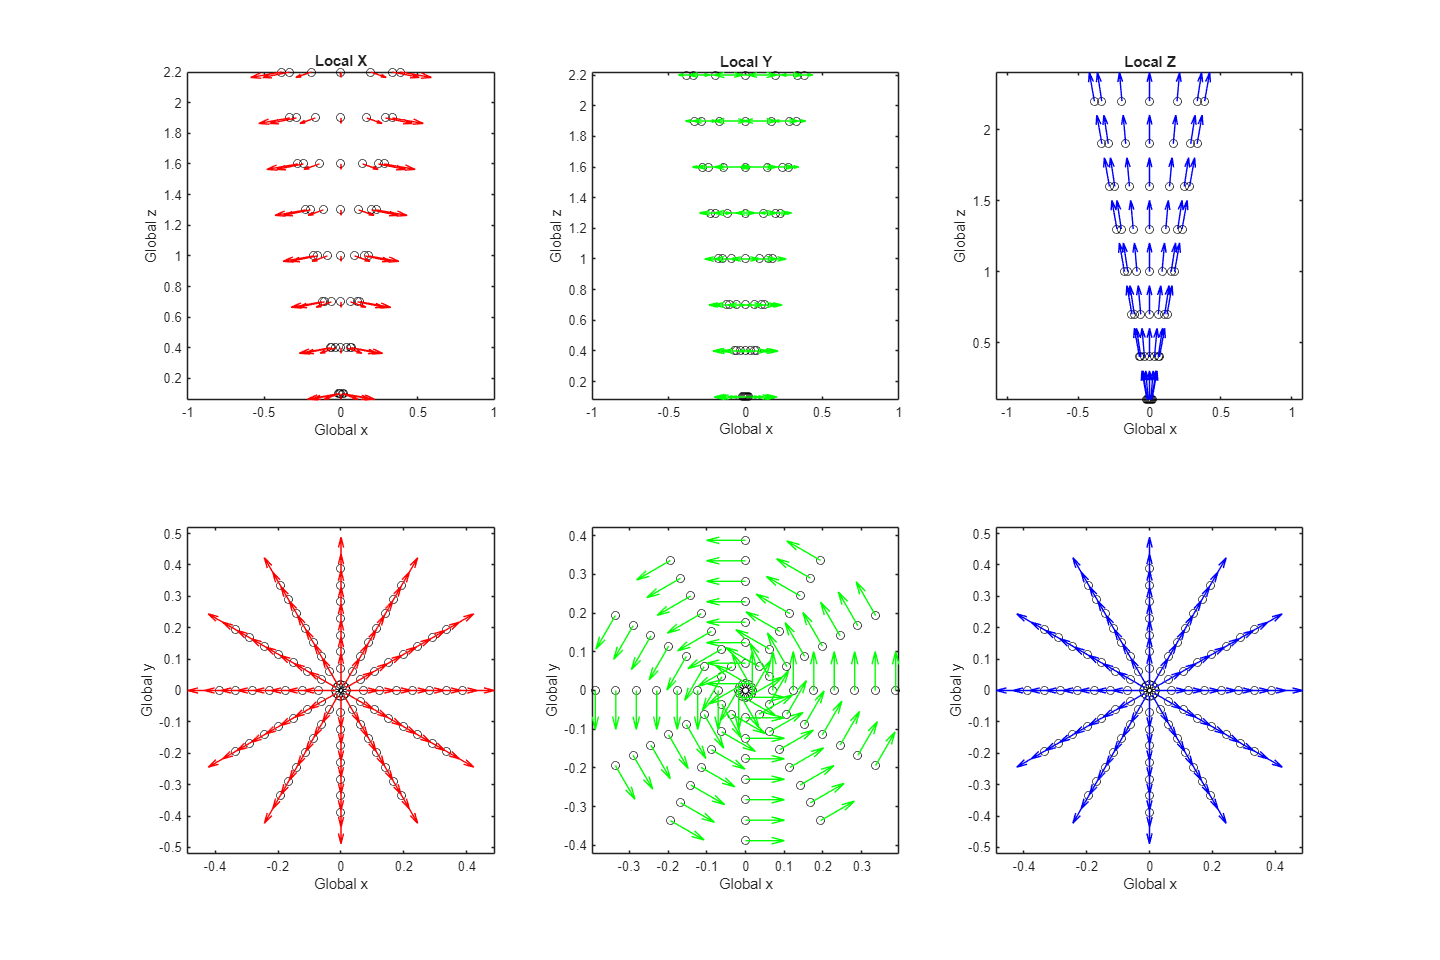

In [3]:
set(gcf, 'Units', 'inches', 'Position', [0, 0, 15, 10]);
for direction_index = 1:3
    if direction_index == 1
        direction = node_x_directions;
        color = 'r';
        label = 'Local X';
    elseif direction_index == 2
        direction = node_y_directions;
        color = 'g';
        label = 'Local Y';
    elseif direction_index == 3
        direction = node_z_directions;
        color = 'b';
        label = 'Local Z';
    end
    subplot(2,3,direction_index)
    x = node_positions(:,1);
    y = node_positions(:,3);
    plot(x,y,'ko');
    hold on;
    u = direction(:,1);
    v = direction(:,3);
    quiver(x,y,u,v,color);
    axis('equal');
    title(label)
    xlabel('Global x')
    ylabel('Global z')
    subplot(2,3,direction_index+3)
    x = node_positions(:,1);
    y = node_positions(:,2);
    plot(x,y,'ko');
    hold on;
    u = direction(:,1);
    v = direction(:,2);
    quiver(x,y,u,v,color);
    axis('equal');
    xlabel('Global x')
    ylabel('Global y')
end

We can see that the geometry is conical while also noting that the local $x$ directions all point perpendicular from the cone's surface, while the local $y$ directions point circumferentially and the $z$ directions point tangential to the cone's surface in the axial direction.

Note that many geometry sources may not include local coordinate system information.  For example, a finite element model typically assumes all data is in a global coordinate system.  If the case is such that all data is in the global coordinate system for a given activity, then the geometry should be defined such that all `node_x_direction` values are $(1, 0, 0)$, `node_y_direction` values are $(0, 1, 0)$, and `node_z_direction` values are $(0, 0, 1)$, which correspond to the global coordinate system directions.

## Creation of Data

For geometry to be meaningful, we might also wish to create a `data` object and a `mode` object, so we can investigate how we can use the geometry to better understand data and modal information using a geometry.  This data may come from a number of sources, such as a test or a simulation.  Therefore we will assume that the user can extract the data from whatever source the data originates from and can package it into standard arrays.  We will assume, as is typical, that data is measured and modes are fit in the local coordinate system directions.  If the users of the data wish to extract the data into a global coordinate system, they must leverage the geometry information along with the provided data or modal information to reconstruct these global motions.

To make data that is easy to visualize in this document, we will generate rigid motions.

In [4]:
% Create a translation motion
abscissa = linspace(0,10,201);
sine_signal = sin(2*pi*abscissa);
ordinates = [];
data_channels = {};
motion_direction = [0.2, -0.5, 0.3];

for node_index = 1:numel(node_ids)
    direction_labels = {'X-','Y-','Z+'};
    direction_vectors = {node_x_directions, node_y_directions, node_z_directions};

    for direction_index = 1:3
        direction_label = direction_labels{direction_index};
        direction_vector = direction_vectors{direction_index};

        data_channels{end+1,1} = sprintf('%d%s', node_ids(node_index), direction_label);

        if contains(direction_label, '-')
            polarity = -1;
        else
            polarity = 1;
        end

        coefficient = dot(direction_vector(node_index,:), motion_direction) * polarity;
        ordinates(end+1,:) = coefficient * sine_signal;
    end
end

We can visualize the different measurements we might have made for this response.

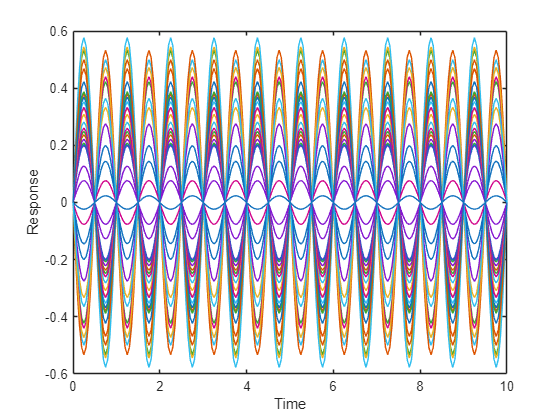

In [5]:
figure;
plot(abscissa, ordinates.')
ylabel('Response')
xlabel('Time')

Let's also generate some rigid body mode shapes.

In [6]:
shape_matrix = [ ...
    -node_x_directions; ...
    -node_y_directions; ...
     node_z_directions];

shape_channels = {};
for d = {'X-','Y-','Z+'}
    for i = 1:numel(node_ids)
        shape_channels{end+1,1} = sprintf('%d%s', node_ids(i), d{1});
    end
end

frequencies = [0, 0, 0]; % Rigid body shapes have 0 Hz frequencies
dampings = [0, 0, 0];    % Rigid body shapes have undefined damping

## Creation of the ESCDF Geometry Object

We will create a dataset with the type `geometry`.  To see the various fields that must be specified, we can use Python's built-in `help` functionality or read the file in Matlab.

In [7]:
disp(fileread('geometry.txt'))

geometry - v0.1.0
-----------------
extends: parameter_set

This group defines a test or analysis geometry, which includes
node positions and local directions associated with each node.

properties
----------
node_id - u8 - num_nodes
node_position - f8 - num_nodes,3
node_x_direction - f8 - num_nodes,3
node_y_direction - f8 - num_nodes,3
node_z_direction - f8 - num_nodes,3
line_connection - u8 - num_lines - variable_length,optional
line_color - u8 - num_lines,3 - optional
element_connection - u8 - num_elements - variable_length,optional
element_color - u8 - num_elements,3 - optional
element_type - str - num_elements - optional, enum:element_types
position_units - str

enumerations
------------
element_types - sphere1, bar2, bar3, tri3, tri6, quad4, quad8, tet4, tet10, hex8, hex20, wedge6, wedge15

notes
-----
Elements in the geometry are just for visualization, and therefore have no "physics" associated with them.
For example, there is no plane strain vs plane stress quad4, they are bot

We can then create the geometry dataset specifying `geometry` as the type and giving it a meaningful name and descriptive name.

In [8]:
es_geo = escdf_dataset( ...
    'cone_geometry', ...
    'geometry', ...
    'A Geometric Representation of a Cone with Local Coordinate Systems');

We can interrogate this geometry object by typing the variable name `es_geo` into the console window to see the empty structure.

In [9]:
es_geo

es_geo = 
  escdf_dataset: cone_geometry (geometry v0.1.0)

  Properties:

      attachment_names: []
           attachments: []
         element_color: []
    element_connection: []
          element_type: []
            line_color: []
       line_connection: []
               node_id: []
         node_position: []
      node_x_direction: []
      node_y_direction: []
      node_z_direction: []
                 notes: []
        position_units: []

Let's start populating the fields we have information for.  We know the node identification numbers, positions, and direction vectors, so we will start with those.

In [10]:
es_geo.node_id = node_ids;
es_geo.node_position = node_positions;
es_geo.node_x_direction = node_x_directions;
es_geo.node_y_direction = node_y_directions;
es_geo.node_z_direction = node_z_directions;

We can use the `validate` method to identify if any required field is still missing.

In [11]:
es_geo.validate()

Required Property position_units is missing.


ans = logical
   0

We can see that the `validate` method is telling us that the `property_units` are missing.  Basically, our geometry object needs to know if the `node_position` values are defined in meters, inches, or any other unit.  We will specify `'m'` here for units.

In [12]:
es_geo.position_units = {'m'};
es_geo.validate()

ans = logical
   1

Even though ESCDF may declare our geometry to be valid, there might be some additional content that we wish to add to the file.  For example, we could specify elements or tracelines on the geometry to improve visualizations; otherwise, the geometry is simply a point cloud that can be challenging to interpret.

To demonstrate different types of visualizations, we will use quadrilateral elements for the first few stations, then triangual elements for the next few, then tracelines for the last few stations.  Note that because the cone "wraps around" in the circumferential direction, we will append the starting circumferential station to the end of the array as well.

Because we made the node identification numbers follow a logical pattern, we could easily use them to, for example, create elements and lines on the geometry.  For each element, we need to specify a type and a connectivity array using the node identification numbers.  Each line needs only a connectivity.  We can also specify a color for each item.

In [13]:
quad_stations = [1,2,3];
tri_stations = [4,5,6];
line_stations = [7,8];
circumferential_nodes = [1,2,3,4,5,6,7,8,9,10,11,12,1]; % Append 1 at the end

element_connectivity = {};
element_types = {};
element_colors = [];
line_connectivity = {};
line_colors = [];

for axial_index = 1:numel(axial_stations)
    axial_station = axial_index;

    for circumferential_index = 1:numel(circumferential_stations)
        node_1 = 100*(axial_station)   + circumferential_nodes(circumferential_index);
        node_2 = 100*(axial_station+1) + circumferential_nodes(circumferential_index);
        node_3 = 100*(axial_station+1) + circumferential_nodes(circumferential_index+1);
        node_4 = 100*(axial_station)   + circumferential_nodes(circumferential_index+1);

        if axial_station < 3
            % Quad element
            element_types{end+1,1} = 'quad4';
            element_connectivity{end+1,1} = uint64([node_1,node_2,node_3,node_4]);
            element_colors(end+1,:) = [0,0,255]; % R G B
        elseif axial_station < 6
            % Tri elements
            element_types{end+1,1} = 'tri3';
            element_connectivity{end+1,1} = uint64([node_1,node_2,node_3]);
            element_colors(end+1,:) = [255,0,0];

            element_types{end+1,1} = 'tri3';
            element_connectivity{end+1,1} = uint64([node_1,node_3,node_4]);
            element_colors(end+1,:) = [255,0,0];
        end
    end

    if axial_station >= 6
        line_connectivity{end+1,1} = uint64(100*(axial_station) + circumferential_nodes);
        line_colors(end+1,:) = [0,255,0]; % R G B
    end
end

We can then apply these to our geometry dataset.

In [14]:
es_geo.element_connection = element_connectivity;
es_geo.element_type = element_types;
es_geo.element_color = element_colors;
es_geo.line_connection = line_connectivity;
es_geo.line_color = line_colors;

We now have our entire geometry completed.  We have defined the node positions, as well as the local orientations associated with measurements at each node.  We have defined the unit system that our geometry is defined in, and we have also added elements and tracelines to aid in visualization.

We will now proceed with constructing our data and shape objects and packaging it all together.

## Creating Data and Shape Objects

We will now create the data and shape objects that reference the geometries.  Again, we can see information about these types by using the Python `help` documentation or by reading the specification files in Matlab.

In [15]:
disp(fileread('mode.txt'))

mode - v0.1.0
-------------
extends: activity_result

This defines a general format for storing modal data.

properties
----------
frequency - f8 - num_modes
damping_ratio - f8 - num_modes - optional
modal_mass - f8 - num_modes - optional
shape - f8 - num_dofs,num_modes - or:mode_type:real_modes
shape - c16 - num_dofs,num_modes - or:mode_type:complex_modes
dof_name - str - num_dofs - regex:^\d+(R?[XYZ]{1,2}[+-])?$
description - str - num_lines - optional

notes
-----
Real or complex modes can be stored using this format.
The dof_name field must be of the form <node_number><direction><polarity>.
node_number is any non-negative integer.
direction is an optional R (to signify rotation) followed by one or two of X, Y, or Z.
polarity is one of + or -.
If the channel does not have a direction or a polarity (e.g. a thermocouple), then
these can be left blank.
Examples of valid channel names include '6', '101X+', '204Z-', '412RY-', '100XX+', '32ZX-'.


In [16]:
disp(fileread('data.txt'))

data - v0.1.0
-------------
extends: activity_result

This defines a general format for storing data.
Specific types of data should inherit from this.

properties
----------
data_type - str - scalar - enum:data_types
channel - str - num_data,num_channels - regex:^\d+(R?[XYZ]{1,2}[+-])?$
channel_name - str - num_data,num_channels - optional
ordinate_unit - str - num_data - or:ordinate_unit:varying_ordinate_units
ordinate_unit - str - scalar - or:ordinate_unit:identical_ordinate_units
abscissa_unit - str - num_data - or:abscissa_unit:varying_abscissa_units
abscissa_unit - str - scalar - or:abscissa_unit:identical_abscissa_units
ordinate - f4 - num_data,num_samples - or:ordinate:real_single_precision
ordinate - c8 - num_data,num_samples - or:ordinate:complex_single_precision
ordinate - f8 - num_data,num_samples - or:ordinate:real_double_precision
ordinate - c16 - num_data,num_samples - or:ordinate:complex_double_precision
abscissa - f4 - num_data,num_samples - or:abscissa:different_spacin

We will now create the `mode` object, again giving a reasonable name and description.

In [17]:
es_mode = escdf_dataset('rigid_modes','mode','Rigid shapes from a modal test.');

We can interrogate this object by typing the variable name `es_mode` in to the command window to identify what we need to define.

In [18]:
es_mode

es_mode = 
  escdf_dataset: rigid_modes (mode v0.1.0)

  Properties:

    attachment_names: []
         attachments: []
       damping_ratio: []
         description: []
            dof_name: []
           frequency: []
          modal_mass: []
               notes: []
               shape: []

We will then assign the variables we have already developed to this object.

In [19]:
% We transpose (.') frequencies and dampings
% to make them column 
es_mode.frequency = frequencies.';
es_mode.damping_ratio = dampings.';
es_mode.shape = shape_matrix;
es_mode.dof_name = shape_channels;

As always, we should validate to ensure that we have defined everything appropriately.

In [20]:
es_mode.validate()

ans = logical
   1

We will do similarly with the data object.

In [21]:
es_data = escdf_dataset('rigid_motion','data','Motions from a rigid body check');

Again we can interrogate this object:

In [22]:
es_data

es_data = 
  escdf_dataset: rigid_motion (data v0.1.0)

  Properties:

            abscissa: []
      abscissa_start: []
       abscissa_step: []
       abscissa_unit: []
    attachment_names: []
         attachments: []
             channel: []
        channel_name: []
           data_type: []
               notes: []
            ordinate: []
       ordinate_unit: []
           timestamp: []

And then we can assign to it.

In [23]:
es_data.abscissa = abscissa.';
es_data.ordinate = ordinates;
es_data.abscissa_unit = {'s'};
es_data.ordinate_unit = {'m/s^2'};
% Need data_channels as an nx1 cell array/string array
es_data.channel = data_channels;
es_data.data_type = {'time response'};

And again `validate` for good measure:

In [24]:
es_data.validate()

ans = logical
   1

## Packaging Objects into an ESCDF File
In order to save to disk, we need to store the data and metadata into an ESCDF File.  We will create the file, add an activity called `'modal_test'` and put the `data` and `mode` object into that activity.  We will then add the `geometry` metadata and link it to the activity.

In [25]:
es_file = escdf();
es_file.add_activity( ...
    'modal_test', ...
    'A modal test that acquired rigid body modes', ...
    datetime('now'));

Let's add the data to the activity.

In [26]:
es_file.add_data_to_activity('modal_test', es_data);
es_file.add_data_to_activity('modal_test', es_mode);

The geometry is not directly data generated by the activity; rather it is metadata that describes the data from the activity.  We will therefore add the geometry object as metadata to the file and link it to the activity.

In [27]:
es_file.add_metadata(es_geo, 'modal_test');

We can then see the entire ESCDF file by typing `es_file` into the console window.

In [28]:
es_file

es_file = 
  escdf object
    Created by dprohe on 13-May-2026 11:17:50

  Metadata:

    cone_geometry (geometry)

  Activities:
    modal_test:
      A modal test that acquired rigid body modes
      Date: 2026-05-13 11:17:50.220
      Data:
        rigid_motion, rigid_modes
      Metadata Links:
        cone_geometry

Now we will write the entire file to disk so it can be shared with other stakeholders for this test.  We will specify the `clobber` argument to be `True` to ensure that any file on disk already is overwritten.

In [29]:
es_file.write_to_disk('modal_test.esf', true);

## Reading and using Geometry from an ESCDF File

After the file is shared, the users of the data may wish to extract the data and the geometry information.  This will be an exercise in bookkeeping.  Any data recieved in ESCDF format may be stored in local or global coordinate system.  **The user should never assume they know how the data is stored, but rather should always reference the linked geometry metadata to identify how the data is defined.**

We will load in the ESCDF file and begin to interrogate it, loading both data and shape results, and then referencing the geometry to transform the data to a global coordinate system for further analysis.

In [30]:
es_file = escdf.load('modal_test.esf');

We can interrogate the loaded file to see the various activity names and data objects.

In [31]:
es_file

es_file = 
  escdf object
    Created by dprohe on 13-May-2026 11:17:50

  Metadata:

    cone_geometry (geometry)

  Activities:
    modal_test:
      A modal test that acquired rigid body modes
      Date: 2026-05-13 11:17:50.000
      Data:
        rigid_modes, rigid_motion
      Metadata Links:
        cone_geometry

We can see there are two data objects in the `modal_test` activity: `rigid_modes` and `rigid_motion`.  We also see a linked metadata `cone_geometry` to this activity.

In the general case where there may be multiple activities and multiple geometries associated with those activities, we would like to specifically define the activity we would like to get data from, and use the metadata links to find the specific metadata associated with that activity.

In [32]:
% Extract the relevant activity
activity_name = 'modal_test';
activity = es_file.activities.(activity_name);
activity_data = activity.data;

% Pull out all metadata attached to the activity, and only keep geometry types
all_metadata = es_file.get_activity_metadata(activity_name);
activity_geometries = {};
for i = 1:numel(all_metadata)
    if all_metadata(i).istype('geometry')
        activity_geometries{end+1} = all_metadata(i);
    end
end

% Check to make sure that we only got one geometry
if isempty(activity_geometries)
    error('No Geometry Found!')
elseif numel(activity_geometries) > 1
    error('Multiple Geometries Found!')
else
    activity_geometry = activity_geometries{1};
end

While this may be more code than simply writing `activity_geometry = es_file.metadata[0]` (Python) or `activity_geometry = es_file.metadata(1)` (Matlab), it is significantly more robust for general, reusable code.  We can verify that `activity_geometry` now points to our `cone_geometry` object.

In [33]:
activity_geometry

activity_geometry = 
  escdf_dataset: cone_geometry (geometry v0.1.0)

  Properties:

      attachment_names: []
           attachments: []
         element_color: u8, (96   3), on disk
    element_connection: u8, (96), on disk
          element_type: str, (96), on disk
            line_color: u8, (3  3), on disk
       line_connection: u8, (3), on disk
               node_id: u8, (96), on disk
         node_position: f8, (96   3), on disk
      node_x_direction: f8, (96   3), on disk
      node_y_direction: f8, (96   3), on disk
      node_z_direction: f8, (96   3), on disk
                 notes: []
        position_units: str, (), on disk

### Using Geometry to Interpret Mode Shapes

We'll start by investigating the modal data.  We can access this by indexing the `activity_data` with the dataset name in Python or calling the `get_data` method of the `activity` object in Matlab.

In [34]:
es_mode = activity.get_data('rigid_modes');

Depending on the information desired from the dataset, the actual analysis steps may be different.  For example, to determine if an accelerometer may have saturated during a test, one may be perfectly content to leave all data in its local coordinate system to perform the analysis.  However, other analyses, such as plotting a mode shape, may involve transforming to a global coordinate system for visualization.  We will assume that here.  We wish to construct a `node_displacements` vector that is the same size and ordering as `node_positions`, where each row corresponds to the $(x,y,z)$ displacement of that node.

For this effort, we will need to go through and multiply each shape coefficient by the corresponding unit vector, while also respecting polarity.  For example, the geometry's `node_x_direction` will specify the positive $x$ axis of the local coordinate system, so we will need to multiply that value by `-1` if we have measured, for example, $101X-$.

While there are perhaps more efficient ways to perform this analysis, recognizing, for example, that all of my local $x$-direction measurements are negative, this code will again present the most general, robust form of this analysis, so readers can use it to analyze arbitrary data.

We will start by extracting relevant geometry information and populating an empty array to store the node displacements.

In [35]:
% Extract relevant geometry information
node_ids = activity_geometry.node_id(:);
node_positions = activity_geometry.node_position(:);
node_x_directions = activity_geometry.node_x_direction(:);
node_y_directions = activity_geometry.node_y_direction(:);
node_z_directions = activity_geometry.node_z_direction(:);

% Create an empty array to populate with displacement data
node_displacements = zeros(numel(node_ids), 3);

For documentation's sake, we will walk through the first item manually.  This will allow explanation of each step.  We will then combine this analysis into a `for` loop to automate the extraction of all data from the mode object.

We will start with the first index of the first shape in the shape matrix, and we will extract this shape coefficient from the shape matrix.

In [36]:
shape_index = 1;
dof_index = 1;
shape_coefficient = es_mode.shape(dof_index, shape_index);

Now we must figure out which degree of freedom this shape coefficient is associated with and how that maps to our `node_displacements` array.  We will interrogate the `dof_name` property to find the channel names.

In [37]:
% This gives a cell array
dof_name = es_mode.dof_name(dof_index);
% The string name is the only item in this cell array
dof_name = dof_name{1}

dof_name = '101X-'

We see that the coefficient corresponds to node 101, and this shape is in the negative $x$ direction.  We therefore need to find the `node_x_direction` associated with node 101, as well as the row into the `node_displacements` array.  We should do this in an automated way so we can execute these operations within a future `for` loop.  Though our current measurements do not contain rotations, general measurements might, so we will also put some error checking into our code to tell users that our code won't work with rotations.

In [38]:
if contains(dof_name, 'R')
    error("We can't handle Rotations yet!")
end
% Node number is everything except last two chars
node_id = str2double(dof_name(1:end-2));
% Second to last char is direction
direction_name = dof_name(end-1);
% Last char is polarity
if dof_name(end) == '-'
    polarity = -1;
else
    polarity = 1;
end
fprintf('Analyzing node %d in direction %s with polarity %d\n', node_id, direction_name, polarity);

Analyzing node 101 in direction X with polarity -1


We should then find the correct index into the node array corresponding to this node number.

In [39]:
node_index = find(node_id == node_ids);
fprintf('Node number %d is at index %d.\n', node_id, node_index(1));

Node number 101 is at index 1.


Now we can extract the correct local direction for that degree of freedom, which when multiplied by the shape coefficient and polarity will give the correct displacement for that component.

In [40]:
if lower(direction_name) == 'x'
    direction = node_x_directions(node_index,:);
elseif lower(direction_name) == 'y'
    direction = node_y_directions(node_index,:);
elseif lower(direction_name) == 'z'
    direction = node_z_directions(node_index,:);
else
    error('Invalid Direction Name %s', direction_name)
end

displacement = polarity * shape_coefficient * direction;
fprintf('Degree of Freedom %s is moving [%g %g %g]\n', dof_name, displacement(1), displacement(2), displacement(3));

Degree of Freedom 101X- is moving [0.969846 0 -0.17101]


We can then add this to our `node_displacements` array at the corresponding node index.  Note that we don't simply assign this value to the `node_displacements` variable at the relevant index.  Each local direction will contribute to the global displacement, so we need to add these contributions together rather than overwrite the contributions.

In [41]:
node_displacements(node_index,:) = node_displacements(node_index,:) + displacement;

We can easily package this into a `for` loop that will read all degrees of freedom and shape coefficients.

In [ ]:
% Create an empty array to populate with displacement data
node_displacements = zeros(numel(node_ids), 3);

for dof_index = 1:numel(es_mode.dof_name(:))
    dof_name = es_mode.dof_name(dof_index);
    dof_name = dof_name{1};
    shape_coefficient = es_mode.shape(dof_index, shape_index);

    if contains(dof_name, 'R')
        error("We can't handle Rotations yet!")
    end

    node_id = str2double(dof_name(1:end-2));
    direction_name = dof_name(end-1);

    if dof_name(end) == '-'
        polarity = -1;
    else
        polarity = 1;
    end

    fprintf('Analyzing node %d in direction %s with polarity %d\n', node_id, direction_name, polarity);

    node_index = find(node_id == node_ids);
    fprintf('  Node number %d is at index %d.\n', node_id, node_index(1));

    if lower(direction_name) == 'x'
        direction = node_x_directions(node_index,:);
    elseif lower(direction_name) == 'y'
        direction = node_y_directions(node_index,:);
    elseif lower(direction_name) == 'z'
        direction = node_z_directions(node_index,:);
    else
        error('  Invalid Direction Name %s', direction_name)
    end

    displacement = polarity * shape_coefficient * direction;
    fprintf('  Degree of Freedom %s is moving [%g %g %g]\n', dof_name, displacement(1), displacement(2), displacement(3));

    node_displacements(node_index,:) = node_displacements(node_index,:) + displacement;
end

Analyzing node 101 in direction X with polarity -1
  Node number 101 is at index 1.
  Degree of Freedom 101X- is moving [0.969846 0 -0.17101]
Analyzing node 102 in direction X with polarity -1
  Node number 102 is at index 2.
  Degree of Freedom 102X- is moving [0.727385 0.419956 -0.148099]
Analyzing node 103 in direction X with polarity -1
  Node number 103 is at index 3.
  Degree of Freedom 103X- is moving [0.242462 0.419956 -0.085505]
Analyzing node 104 in direction X with polarity -1
  Node number 104 is at index 4.
  Degree of Freedom 104X- is moving [3.63634e-33 5.9386e-17 -1.04713e-17]
Analyzing node 105 in direction X with polarity -1
  Node number 105 is at index 5.
  Degree of Freedom 105X- is moving [0.242462 -0.419956 0.085505]
Analyzing node 106 in direction X with polarity -1
  Node number 106 is at index 6.
  Degree of Freedom 106X- is moving [0.727385 -0.419956 0.148099]
Analyzing node 107 in direction X with polarity -1
  Node number 107 is at index 7.
  Degree of Free

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Because we constructed the rigid shapes for this example as the displacements in the global $x$, $y$, and $z$ directions, we see that when we reconstruct the global displacements we indeed end up with the vector `[1, 0, 0]` for each node in the model in the first mode shape.

In [66]:
node_displacements

node_displacements = 96×3 double
    1.0000         0         0
    1.0000    0.0000         0
    1.0000   -0.0000   -0.0000
    1.0000   -0.0000         0
    1.0000    0.0000         0
    1.0000   -0.0000         0
    1.0000    0.0000         0
    1.0000   -0.0000         0
    1.0000   -0.0000         0
    1.0000    0.0000         0
    1.0000    0.0000   -0.0000
    1.0000    0.0000         0
    1.0000         0         0
    1.0000    0.0000         0
    1.0000   -0.0000   -0.0000
...

Note, however, that this has only performed the transformation operation for the first mode in the mode shape matrix.  We may wish to repeat this operation for each mode and construct a complete "global mode shape matrix" that is `num_dofs` $\times$ `num_modes`.  We would then flatten this array and perform the same operation for each mode.  It would generally be useful to package a tool like this into a generic function that can be pointed at any dataset.  In this case we will handle the rotations as well, creating a second shape matrix for rotations if requested.

Let's call this function on our data to verify that it works correctly.

In [44]:
[dof_names, global_displacements, global_rotations] = transform_shapes_to_global(es_mode, activity_geometry, true);

function varargout = transform_shapes_to_global(es_mode, es_geo, return_rotations, verbose)
    % Accepts a "mode" dataset and converts the shapes to global.
    %
    % Parameters
    % ----------
    % es_mode : escdf.Dataset
    %   ESCDF dataset with type "mode".
    % es_geo : escdf.Dataset
    %   ESCDF dataset with type "geometry".
    % return_rotations : logical
    %   If true, return rotation matrix as well.
    % verbose : logical
    %   If true, print debugging statements.
    %
    % Returns
    % -------
    % global_dof_names
    % global_shape_displacement_matrix
    % global_shape_rotation_matrix (optional)
    
    if nargin < 3
        return_rotations = false;
    end
    if nargin < 4
        verbose = false;
    end
    
    num_modes = size(es_mode.shape(:), 2);
    num_nodes = size(es_geo.node_id(:), 1);
    
    node_ids = es_geo.node_id(:);
    node_index_mapping = containers.Map('KeyType','double','ValueType','double');
    for i = 1:num_nodes
        node_index_mapping(node_ids(i)) = i;
    end
    
    global_shape_displacement_matrix = zeros(3, num_nodes, num_modes);
    if verbose
        fprintf('Created [%d %d %d] output array for displacements\n', size(global_shape_displacement_matrix));
    end
    
    if return_rotations
        global_shape_rotation_matrix = zeros(3, num_nodes, num_modes);
        if verbose
            fprintf('Created [%d %d %d] output array for rotations\n', size(global_shape_rotation_matrix));
        end
    end
    
    global_dof_names = cell(num_nodes*3,1);
    idx = 1;
    for i = 1:num_nodes
        for d = {'X+','Y+','Z+'}
            global_dof_names{idx} = sprintf('%d%s', node_ids(i), d{1});
            idx = idx + 1;
        end
    end
    
    if verbose
        disp('Created output degree of freedom names:')
        disp(global_dof_names)
    end
    
    name_pattern = '(\d+)([a-zA-Z]+)([+-])';
    
    for dof_index = 1:numel(es_mode.dof_name(:))
        dof_name = es_mode.dof_name(dof_index);
        dof_name = dof_name{1};
        shape_row = es_mode.shape(dof_index,:);
    
        name_match = regexp(dof_name, name_pattern, 'tokens', 'once');
        node_id = str2double(name_match{1});
        direction_str = name_match{2};
        polarity = str2double([name_match{3}, '1']);
    
        if contains(direction_str, 'R') && ~return_rotations
            if verbose
                fprintf('Skipping DoF %s because rotations not requested.\n', dof_name);
            end
            continue
        end
    
        if verbose
            fprintf('Analyzing DoF %s with node number %d, direction %s, and polarity %d\n', ...
                dof_name, node_id, direction_str, polarity);
        end
    
        node_index = node_index_mapping(node_id);
        if verbose
            fprintf('  Node %d is at index %d\n', node_id, node_index);
        end
    
        if contains(direction_str, 'X')
            direction = polarity * es_geo.node_x_direction(node_index,:);
        elseif contains(direction_str, 'Y')
            direction = polarity * es_geo.node_y_direction(node_index,:);
        elseif contains(direction_str, 'Z')
            direction = polarity * es_geo.node_z_direction(node_index,:);
        else
            error('Unknown Direction')
        end
    
        if verbose
            fprintf('  DoF %s is pointing [%g %g %g]\n', dof_name, direction(1), direction(2), direction(3));
        end
    
        dof_contributions = direction(:) * shape_row; % 3 x num_modes
    
        if verbose
            disp('  DoF contributions:')
            disp(dof_contributions)
        end
    
        if contains(direction_str, 'R')
            global_shape_rotation_matrix(:,node_index,:) = squeeze(global_shape_rotation_matrix(:,node_index,:)) + dof_contributions;
        else
            global_shape_displacement_matrix(:,node_index,:) = squeeze(global_shape_displacement_matrix(:,node_index,:)) + dof_contributions;
        end
    end
    
    global_shape_displacement_matrix = reshape(global_shape_displacement_matrix, [], num_modes);
    
    if return_rotations
        global_shape_rotation_matrix = reshape(global_shape_rotation_matrix, [], num_modes);
        varargout = {global_dof_names, global_shape_displacement_matrix, global_shape_rotation_matrix};
    else
        varargout = {global_dof_names, global_shape_displacement_matrix};
    end
end

We can set up a `table` to present this data in a nice way.

In [45]:
mode_names = arrayfun(@(i) sprintf('Mode %d', i), 1:size(global_displacements,2), 'UniformOutput', false);

table_disp = array2table(global_displacements, 'VariableNames', mode_names, 'RowNames', dof_names);
table_rot  = array2table(global_rotations,    'VariableNames', mode_names, 'RowNames', dof_names);

We can verify that for the global $x$-direction mode, all global $x$ degrees of freedom have a shape coefficient of 1, and likewise for $y$ and $z$.

In [46]:
table_disp

,Mode 1,Mode 2,Mode 3
101X+,1.0000,0,0
101Y+,0,1,0
101Z+,0,0,1.0000
102X+,1,8.6736e-18,0
102Y+,8.6736e-18,1,0
102Z+,0,0,1.0000
103X+,1,-4.5103e-17,-1.3878e-17
103Y+,-4.5103e-17,1,0
103Z+,-1.3878e-17,0,1.0000
104X+,1,-6.9333e-33,0


Similarly, we can verify that there were no rotations in the model, so the rotation matrix is zeros.

In [47]:
table_rot

,Mode 1,Mode 2,Mode 3
101X+,0,0,0
101Y+,0,0,0
101Z+,0,0,0
102X+,0,0,0
102Y+,0,0,0
102Z+,0,0,0
103X+,0,0,0
103Y+,0,0,0
103Z+,0,0,0
104X+,0,0,0


### Using Geometry to Interpret Data

Now we will interpret the time data, utilizing the geometry to aid in transforming the data to a global coordinate system for visualization.

In [48]:
es_data = activity.get_data('rigid_motion');

Depending on the information desired and the type of data, the actual analysis steps may be different.  For example, to determine if an accelerometer may have saturated during a test, one may be perfectly content to leave all data in its local coordinate system to perform the analysis.  However, other analyses, such as plotting deflections over time, may involve transforming to a global coordinate system for visualization.  We will assume that here.  Additionally, if other types of data were provided instead of a time history, such as a power spectral density or frequency response function, then the steps to transform the coordinate systems of those data may involve multiple transformation steps for the "row" and "column degrees of freedom.

In this case, we wish to construct a `node_displacements` array that is the same size and ordering as `node_positions`, where each row corresponds to the $(x, y, z)$ displacement of that node.

For this effort, we will need to go through and multiply each local displacement by the corresponding unit vector of that degree of freedom, while also respecting polarity.  For example, the geometry’s `node_x_direction` will specify the positive $x$ axis of the local coordinate system, so we will need to multiply that value by -1 if we have measured, for example, $101X−$.

While there are perhaps more efficient ways to perform this analysis, recognizing, for example, that all of the local $x$-direction measurements are negative, this code will again present the most general, robust form of this analysis so readers can use it to analyze arbitrary data.

We will start by extracting relevant geometry information and populating an empty array to store the node displacements.

In [49]:
% Extract relevant geometry information
node_ids = activity_geometry.node_id(:);
node_positions = activity_geometry.node_position(:);
node_x_directions = activity_geometry.node_x_direction(:);
node_y_directions = activity_geometry.node_y_direction(:);
node_z_directions = activity_geometry.node_z_direction(:);

% Create an empty array to populate with displacement data
node_displacements = zeros(numel(node_ids), 3);

For documentation's sake, we will walk through the first item manually.  This will allow for explaination of each step.  We will then combine this analysis into a `for` loop to automate extraction of all data from the `data` object.

Since our time response starts at 0 displacement, we will skip the first time step and start looking at the second time step to demonstrate the process (otherwise we will simply recover an array of zeros, which will not give us the intuition that we have set up the analysis correctly).  We will start with the index of the second time step in the data, and we will extract the displacement value from the ordinate.

In [50]:
timestep_index = 2;
dof_index = 1;
local_disp = es_data.ordinate(dof_index, timestep_index);

Now we must figure out which degree of freedom this shape coefficient is associated with and how that maps to our `node_displacements` array.  We will interrogate the `channel` property to find the channel names.

Recall that the `channel` shape is actually `num_data` $\times$ `num_channels`, because it can store higher dimensional datasets like frequency response functions or cross-power spectral density functions, which may contain more than one degree of freedom per function; for example each frequency response function has both a response degree of freedom and a reference degree of freedom.  For a time history, there is only one channel associated with each signal, so the `channel` property has a shape of `num_data` $\times$ `1`, but it is still two dimensional and needs two indices.

In [51]:
dof_name = es_data.channel(dof_index,1);
dof_name = dof_name{1}

dof_name = '101X-'

We see that the coefficient corresponds to node 101, and this shape is in the negative $x$ direction. We therefore need to find the `node_x_direction` associated with node 101, as well as the row index into the `node_displacements` array. We should do this in an automated way so we can execute these operations within a future for loop. Though our current measurements do not contain rotations, general measurements might, so we will also put some error checking into our code to tell users that our code won’t work with rotations.

In [52]:
if contains(dof_name, 'R')
    error("We can't handle Rotations yet!")
end
node_id = str2double(dof_name(1:end-2));
direction_name = dof_name(end-1);

if dof_name(end) == '-'
    polarity = -1;
else
    polarity = 1;
end

fprintf('Analyzing node %d in direction %s with polarity %d\n', node_id, direction_name, polarity);

Analyzing node 101 in direction X with polarity -1


We should then find the correct index into the node array corresponding to this node number.

In [53]:
node_index = find(node_id == node_ids);
fprintf('Node number %d is at index %d.\n', node_id, node_index(1));

Node number 101 is at index 1.


Now we can extract the correct local direction for that degree of freedom, which when multiplied by the local displacement and polarity will give the correct displacement for that component.

In [54]:
if lower(direction_name) == 'x'
    direction = node_x_directions(node_index,:);
elseif lower(direction_name) == 'y'
    direction = node_y_directions(node_index,:);
elseif lower(direction_name) == 'z'
    direction = node_z_directions(node_index,:);
else
    error('Invalid Direction Name %s', direction_name)
end

displacement = polarity * local_disp * direction;
fprintf('Degree of Freedom %s is moving [%g %g %g]\n', dof_name, displacement(1), displacement(2), displacement(3));

Degree of Freedom 101X- is moving [0.0440863 0 -0.0077736]


We can then add this to our `node_displacements` array at the corresponding node index. Note that we don’t simply assign this value to the `node_displacements` variable at the relevant index. Each local direction will contribute to the global displacement, so we need to add these contributions together rather than overwrite the contributions.

In [55]:
node_displacements(node_index,:) = node_displacements(node_index,:) + displacement;

We can easily package this into a `for` loop that will read all degrees of freedom and local displacement values.

In [ ]:
% Create an empty array to populate with displacement data
node_displacements = zeros(numel(node_ids), 3);

for dof_index = 1:size(es_data.ordinate(:),1)
    dof_name = es_data.channel(dof_index,1);
    dof_name = dof_name{1};
    local_disp = es_data.ordinate(dof_index, timestep_index);

    if contains(dof_name, 'R')
        error("We can't handle Rotations yet!")
    end

    node_id = str2double(dof_name(1:end-2));
    direction_name = dof_name(end-1);

    if dof_name(end) == '-'
        polarity = -1;
    else
        polarity = 1;
    end

    fprintf('Analyzing node %d in direction %s with polarity %d\n', node_id, direction_name, polarity);

    node_index = find(node_id == node_ids);
    fprintf('  Node number %d is at index %d.\n', node_id, node_index(1));

    if lower(direction_name) == 'x'
        direction = node_x_directions(node_index,:);
    elseif lower(direction_name) == 'y'
        direction = node_y_directions(node_index,:);
    elseif lower(direction_name) == 'z'
        direction = node_z_directions(node_index,:);
    else
        error('  Invalid Direction Name %s', direction_name)
    end

    displacement = polarity * local_disp * direction;
    fprintf('  Degree of Freedom %s is moving [%g %g %g]\n', dof_name, displacement(1), displacement(2), displacement(3));

    node_displacements(node_index,:) = node_displacements(node_index,:) + displacement;
end

Analyzing node 101 in direction X with polarity -1
  Node number 101 is at index 1.
  Degree of Freedom 101X- is moving [0.0440863 0 -0.0077736]
Analyzing node 101 in direction Y with polarity -1
  Node number 101 is at index 1.
  Degree of Freedom 101Y- is moving [-0 -0.154508 -0]
Analyzing node 101 in direction Z with polarity 1
  Node number 101 is at index 1.
  Degree of Freedom 101Z+ is moving [0.0177171 0 0.100479]
Analyzing node 102 in direction X with polarity -1
  Node number 102 is at index 2.
  Degree of Freedom 102X- is moving [-0.0336614 -0.0194344 0.00685363]
Analyzing node 102 in direction Y with polarity -1
  Node number 102 is at index 2.
  Degree of Freedom 102Y- is moving [0.082355 -0.142643 -0]
Analyzing node 102 in direction Z with polarity 1
  Node number 102 is at index 2.
  Degree of Freedom 102Z+ is moving [0.0131098 0.00756897 0.0858515]
Analyzing node 103 in direction X with polarity -1
  Node number 103 is at index 3.
  Degree of Freedom 103X- is moving [-0.

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



We constructed the global response with sinusoidal motion in the direction

In [64]:
motion_direction

motion_direction = 1×3 double
    0.2000   -0.5000    0.3000

We can therefore see that the displacements we have recovered are some fraction of this value; all displacements are equal to `0.30901699` times the motion direction.

In [58]:
node_displacements ./ motion_direction

ans = 96×3 double
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
    0.3090    0.3090    0.3090
...

Note, however, that this has only performed the transformation operation on the second time step of the response.  We would generally wish to repeat this operation for each time step and contruct a complete "global time response" array that is `num_dofs` $\times$ `num_timesteps`.  We would then flatten this array and perform the same operation for each time step.  It would generally be useful to package a tool like this into a generic function that can be pointed at any dataset.  In this case, we will handle the rotations as well, creating a second time history array for rotations if requested.

Let's call this function on our data to verify that it works correctly.

In [59]:
[dof_names, global_displacements, global_rotations] = transform_time_data_to_global(es_data, activity_geometry, true);

function varargout = transform_time_data_to_global(es_data, es_geo, return_rotations, verbose)
% Accepts a "data" dataset and converts the ordinate to global.
%
% Parameters
% ----------
% es_data : escdf.Dataset
%   ESCDF dataset with type "data" containing time response information.
% es_geo : escdf.Dataset
%   ESCDF dataset with type "geometry".
% return_rotations : logical
%   If true, return rotation matrix as well.
% verbose : logical
%   If true, print debugging statements.

    if nargin < 3
        return_rotations = false;
    end
    if nargin < 4
        verbose = false;
    end
    
    if ~strcmp(es_data.data_type(1), {'time response'})
        error('transform_time_data_to_global only works on "time response" data.')
    end
    
    num_timesteps = size(es_data.ordinate(:), 2);
    num_nodes = size(es_geo.node_id(:), 1);
    
    node_ids = es_geo.node_id(:);
    node_index_mapping = containers.Map('KeyType','double','ValueType','double');
    for i = 1:num_nodes
        node_index_mapping(node_ids(i)) = i;
    end
    
    global_displacement_matrix = zeros(3, num_nodes, num_timesteps);
    if verbose
        fprintf('Created [%d %d %d] output array for displacements\n', size(global_displacement_matrix));
    end
    
    if return_rotations
        global_rotation_matrix = zeros(3, num_nodes, num_timesteps);
        if verbose
            fprintf('Created [%d %d %d] output array for rotations\n', size(global_rotation_matrix));
        end
    end
    
    global_dof_names = cell(num_nodes*3,1);
    idx = 1;
    for i = 1:num_nodes
        for d = {'X+','Y+','Z+'}
            global_dof_names{idx} = sprintf('%d%s', node_ids(i), d{1});
            idx = idx + 1;
        end
    end
    
    if verbose
        disp('Created output degree of freedom names:')
        disp(global_dof_names)
    end
    
    name_pattern = '(\d+)([a-zA-Z]+)([+-])';
    
    for dof_index = 1:size(es_data.ordinate(:),1)
        dof_name = es_data.channel(dof_index,1);
        dof_name = dof_name{1};
        ordinate_row = es_data.ordinate(dof_index,:);
    
        name_match = regexp(dof_name, name_pattern, 'tokens', 'once');
        node_id = str2double(name_match{1});
        direction_str = name_match{2};
        polarity = str2double([name_match{3}, '1']);
    
        if contains(direction_str, 'R') && ~return_rotations
            if verbose
                fprintf('Skipping DoF %s because rotations not requested.\n', dof_name);
            end
            continue
        end
    
        if verbose
            fprintf('Analyzing DoF %s with node number %d, direction %s, and polarity %d\n', ...
                dof_name, node_id, direction_str, polarity);
        end
    
        node_index = node_index_mapping(node_id);
        if verbose
            fprintf('  Node %d is at index %d\n', node_id, node_index);
        end
    
        if contains(direction_str, 'X')
            direction = polarity * es_geo.node_x_direction(node_index,:);
        elseif contains(direction_str, 'Y')
            direction = polarity * es_geo.node_y_direction(node_index,:);
        elseif contains(direction_str, 'Z')
            direction = polarity * es_geo.node_z_direction(node_index,:);
        else
            error('Unknown Direction')
        end
    
        if verbose
            fprintf('  DoF %s is pointing [%g %g %g]\n', dof_name, direction(1), direction(2), direction(3));
        end
    
        dof_contributions = direction(:) * ordinate_row; % 3 x num_timesteps
    
        if verbose
            disp('  DoF contributions:')
            disp(dof_contributions)
        end
    
        if contains(direction_str, 'R')
            global_rotation_matrix(:,node_index,:) = squeeze(global_rotation_matrix(:,node_index,:)) + dof_contributions;
        else
            global_displacement_matrix(:,node_index,:) = squeeze(global_displacement_matrix(:,node_index,:)) + dof_contributions;
        end
    end
    
    global_displacement_matrix = reshape(global_displacement_matrix, [], num_timesteps);
    
    if return_rotations
        global_rotation_matrix = reshape(global_rotation_matrix, [], num_timesteps);
        varargout = {global_dof_names, global_displacement_matrix, global_rotation_matrix};
    else
        varargout = {global_dof_names, global_displacement_matrix};
    end
end

We can set up a `table` to present this data in a nice way.

In [60]:
time_names = arrayfun(@(t) sprintf('t=%0.2fs', t), es_data.abscissa(:), 'UniformOutput', false);

table_disp = array2table(global_displacements, 'VariableNames', time_names, 'RowNames', dof_names);
table_rot  = array2table(global_rotations,    'VariableNames', time_names, 'RowNames', dof_names);

We can verify that the translation looks rigid.  All $x$-values are identical at each time step, likewise for $y$ and $z$.

In [61]:
table_disp(:,1:10)

,t=0.00s,t=0.05s,t=0.10s,t=0.15s,t=0.20s,t=0.25s,t=0.30s,t=0.35s,t=0.40s,t=0.45s
101X+,0,0.0618,0.1176,0.1618,0.1902,0.2000,0.1902,0.1618,0.1176,0.0618
101Y+,0,-0.1545,-0.2939,-0.4045,-0.4755,-0.5000,-0.4755,-0.4045,-0.2939,-0.1545
101Z+,0,0.0927,0.1763,0.2427,0.2853,0.3000,0.2853,0.2427,0.1763,0.0927
102X+,0,0.0618,0.1176,0.1618,0.1902,0.2000,0.1902,0.1618,0.1176,0.0618
102Y+,0,-0.1545,-0.2939,-0.4045,-0.4755,-0.5000,-0.4755,-0.4045,-0.2939,-0.1545
102Z+,0,0.0927,0.1763,0.2427,0.2853,0.3000,0.2853,0.2427,0.1763,0.0927
103X+,0,0.0618,0.1176,0.1618,0.1902,0.2000,0.1902,0.1618,0.1176,0.0618
103Y+,0,-0.1545,-0.2939,-0.4045,-0.4755,-0.5000,-0.4755,-0.4045,-0.2939,-0.1545
103Z+,0,0.0927,0.1763,0.2427,0.2853,0.3000,0.2853,0.2427,0.1763,0.0927
104X+,0,0.0618,0.1176,0.1618,0.1902,0.2000,0.1902,0.1618,0.1176,0.0618


Similarly, we can verify that there were no rotations in the model, so the rotation matrix is zeros.

In [62]:
table_rot(:,1:10)

,t=0.00s,t=0.05s,t=0.10s,t=0.15s,t=0.20s,t=0.25s,t=0.30s,t=0.35s,t=0.40s,t=0.45s
101X+,0,0,0,0,0,0,0,0,0,0
101Y+,0,0,0,0,0,0,0,0,0,0
101Z+,0,0,0,0,0,0,0,0,0,0
102X+,0,0,0,0,0,0,0,0,0,0
102Y+,0,0,0,0,0,0,0,0,0,0
102Z+,0,0,0,0,0,0,0,0,0,0
103X+,0,0,0,0,0,0,0,0,0,0
103Y+,0,0,0,0,0,0,0,0,0,0
103Z+,0,0,0,0,0,0,0,0,0,0
104X+,0,0,0,0,0,0,0,0,0,0


## Summary

The `geometry` data type in ESCDF is instrumental for documenting sensor orientation information.  One should never assume that data is provided in a global coordinate system, rather a `geometry` object should be used to transform local degree-of-freedom information into a global coordinate system if that is what is desired.  By utilizing the encoded channel names, we can map values in the mode shape matrix or the data ordinate to local displacement directions, which when multiplied by the value produce a contribution to the global response.  Summing all of these contributions produces the full global response.